In [4]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Physical constants
hbar = 1.055e-34   # [J s]
m_e  = 9.109e-31   # [kg]
eV   = 1.602e-19   # [J]


def build_bloch_laplacian_1d(
    N: int,
    dx: float,
    k: float,
) -> sp.csr_matrix:
    """
    Construct the 1D finite-difference Laplacian on one periodic cell
    with Bloch boundary conditions.

    The state vector is

        psi = [psi_0, psi_1, ..., psi_{N-1}]

    over a cell of length

        a = N dx

    with Bloch condition

        psi(x + a) = exp(i k a) psi(x).
    """

    a = N * dx

    main = -2.0 * np.ones(N)
    off = np.ones(N - 1)

    L = sp.diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="lil",
        dtype=complex,
    )

    # Bloch boundary couplings
    L[0, -1] = np.exp(-1j * k * a)
    L[-1, 0] = np.exp(1j * k * a)

    return L.tocsr() / dx**2


def build_bloch_hamiltonian_1d(
    N: int,
    dx: float,
    k: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> sp.csr_matrix:
    """
    Construct the free-electron Bloch Hamiltonian

        H(k) = -(hbar^2 / 2m) L(k)

    where L(k) is the Bloch Laplacian.
    """

    L_k = build_bloch_laplacian_1d(N, dx, k)

    H_k = -(hbar**2 / (2.0 * mass)) * L_k

    return H_k


def calculate_dispersion(
    k_vals: np.ndarray,
    N_bands: int,
    N: int,
    dx: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Compute the lowest N_bands eigenvalues of H(k)
    for each k in k_vals.
    """

    E_k = []

    for k in k_vals:
        H_k = build_bloch_hamiltonian_1d(
            N=N,
            dx=dx,
            k=k,
            mass=mass,
            hbar=hbar,
        )

        eigvals = np.linalg.eigvalsh(H_k.toarray())

        E_k.append(eigvals[:N_bands])

    return np.array(E_k)

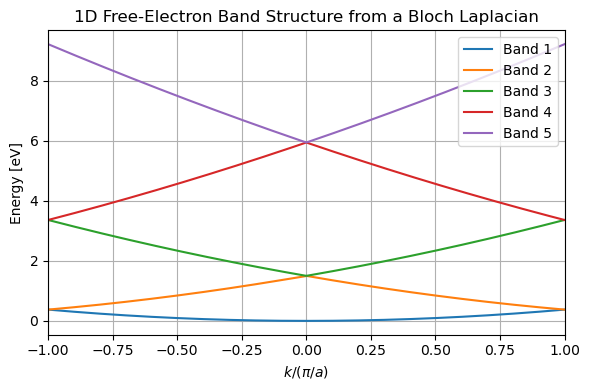

In [5]:
# Parameters
N_uc = 32
L_uc = 1e-9
dx = L_uc / N_uc

k_vals = np.linspace(-np.pi / L_uc, np.pi / L_uc, 500)
N_bands = 5

# Compute bands
Ek_joules = calculate_dispersion(
    k_vals=k_vals,
    N_bands=N_bands,
    N=N_uc,
    dx=dx,
)

Ek_eV = Ek_joules / eV

# Dimensionless plotting variable: k / (pi/a)
k_vals_pi = k_vals * L_uc / np.pi

# Plot
plt.figure(figsize=(6, 4))

for n in range(N_bands):
    plt.plot(
        k_vals_pi,
        Ek_eV[:, n],
        label=f"Band {n + 1}",
    )

plt.xlim([-1, 1])
plt.xlabel(r"$k/(\pi/a)$")
plt.ylabel("Energy [eV]")
plt.title("1D Free-Electron Band Structure from a Bloch Laplacian")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Inspecting Bloch Eigenstates

The band diagram gives the eigenvalues of the Bloch Hamiltonian,

$$
H(k)u_{n,k}
=
E_n(k)u_{n,k}
$$

where $k$ is the Bloch wave vector, $n$ is the band index, $E_n(k)$ is the energy of band $n$ at wave vector $k$, and $u_{n,k}$ is the eigenvector defined inside one computational unit cell.

The important point is that the band diagram only shows the spectrum. It tells us the allowed energies, but it does not show what the corresponding states look like. To understand the states, we need to inspect the eigenvectors.

In this finite-difference model, the state vector is

$$
u_{n,k}
  =
    \begin{bmatrix}
      u_0 & u_1 & \cdots &u_{N-1}
    \end{bmatrix}^\mathsf{T}
$$

where each component is the value of the numerical wavefunction at one grid point inside the unit cell. The unit cell has length

$$
a = N\Delta x
$$

where $N$ is the number of grid points and $\Delta x$ is the grid spacing.

The Bloch condition is
$$
\psi(x+a)=e^{ika}\psi(x)
$$

In the numerical model, this phase is inserted into the boundary entries of the finite-difference Laplacian. The Hamiltonian $H(k)$ is therefore a finite matrix whose boundary terms depend on $k$.

For the free electron, the Hamiltonian is only the kinetic-energy operator,

$$
H(k)
=
-\frac{\hbar^2}{2m}L(k)
$$

where $L(k)$ is the Bloch Laplacian. Because there is no potential, the eigenstates are extended states. Their probability density is essentially uniform across the unit cell. The interesting structure is therefore not localization. The interesting structure is phase and Fourier content.

The full Bloch state may be written conceptually as

$$
\psi_{n,k}(x)
=
e^{ikx}u_{n,k}(x)
$$

where $u_{n,k}(x)$ is cell-periodic. In this implementation, the Bloch phase has been pushed into the boundary condition, so the numerical eigenvector already carries the boundary-compatible phase structure.

For a free electron in a periodic representation, the continuum energies are folded into the first Brillouin zone. The folded free-electron bands have the form

$$
E_\ell(k)
=
\frac{\hbar^2}{2m}
\left(k+G_\ell\right)^2
$$

where

$$
G_\ell
=
\frac{2\pi \ell}{a}
$$

is a reciprocal lattice vector.

The multiple bands in the free-electron band diagram are therefore not caused by bonding, antibonding, or lattice scattering. They are folded parabolas. The folding comes from describing the problem inside a single unit cell while restricting $k$ to the first Brillouin zone.

The Fourier content of an eigenvector is therefore a useful diagnostic. For the free electron, each eigenstate should be dominated by a small number of reciprocal-lattice components. This tells us which folded plane-wave component the numerical eigenstate represents.

A periodic potential changes this picture. If we add a cell-periodic potential such as

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

then the Hamiltonian becomes

$$
H(k)
=
-\frac{\hbar^2}{2m}L(k)
+
V
$$

This potential contains reciprocal-lattice components at

$$
G = \pm \frac{2\pi}{a}
$$

so it couples plane-wave components whose wave vectors differ by reciprocal lattice vectors. At the Brillouin-zone boundary, two folded free-electron states become degenerate. The periodic potential mixes them and splits their energies.

This splitting is the origin of the band gap in the nearly-free-electron picture.

The computational sequence is therefore:

1. Build the Bloch Laplacian $L(k)$.
2. Construct the Hamiltonian $H(k)$.
3. Solve the eigenvalue problem for each $k$.
4. Plot $E_n(k)$ to obtain the band structure.
5. Inspect $u_{n,k}$ to understand the internal structure of the states.
6. Use Fourier content to identify which reciprocal-lattice components dominate each state.
7. Add a periodic potential and observe how degeneracies split at the Brillouin-zone boundary.

For this reason, the states should be called Bloch eigenstates or cell eigenvectors at this stage. It is better not to call them orbitals yet. The word orbital becomes more appropriate when the model contains localized basis functions, atomic sites, tight-binding states, or Wannier-like functions.

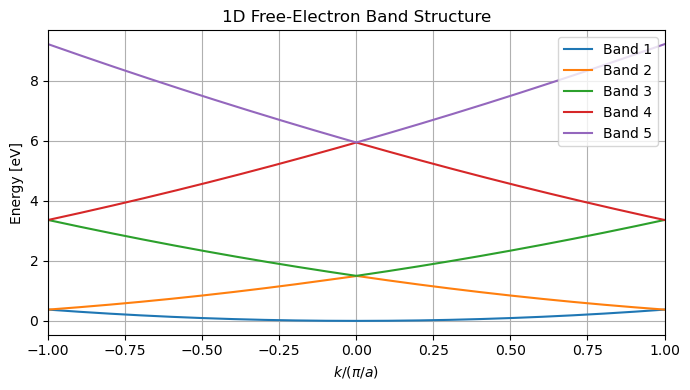

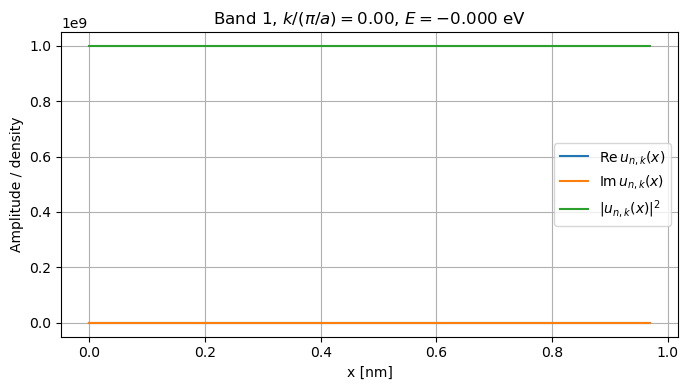

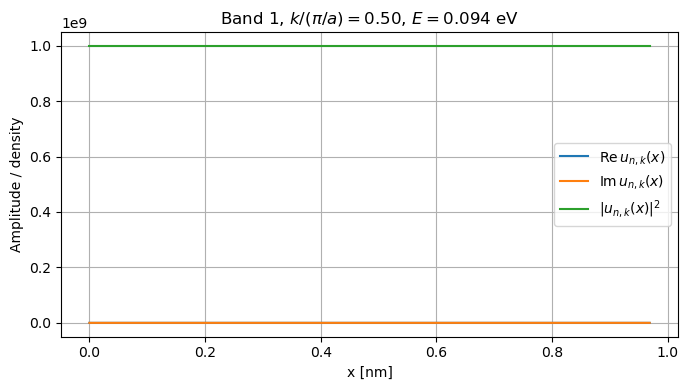

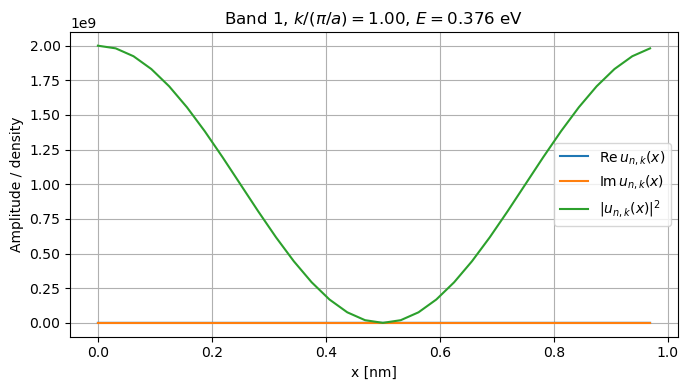

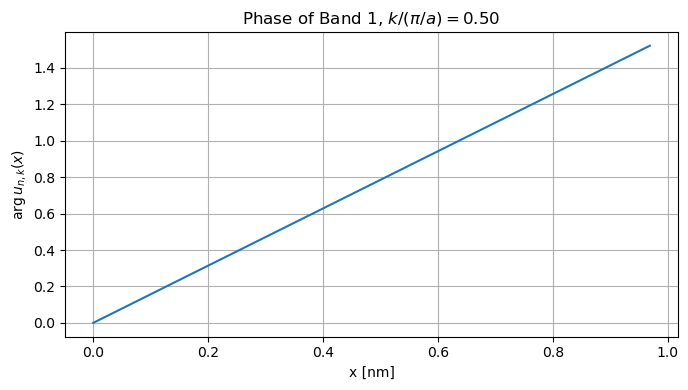

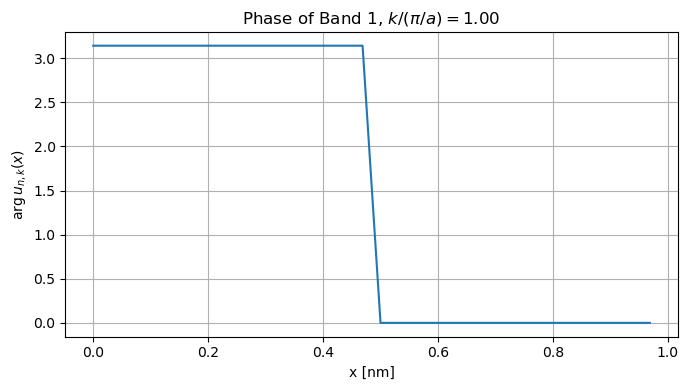

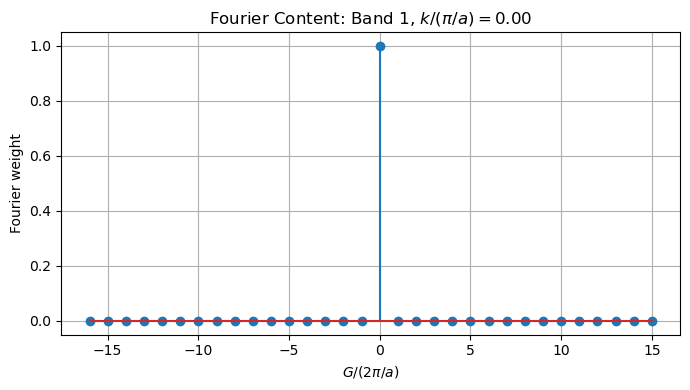

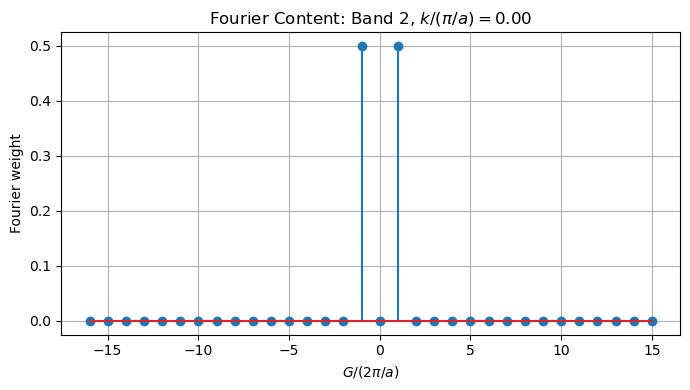

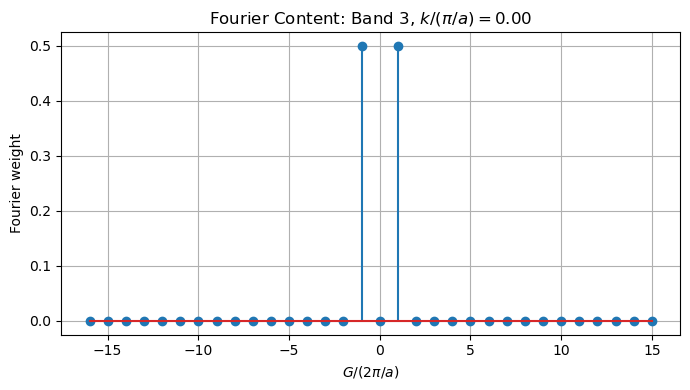

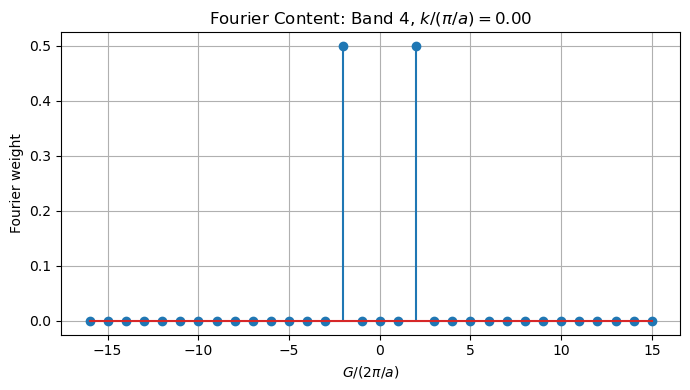

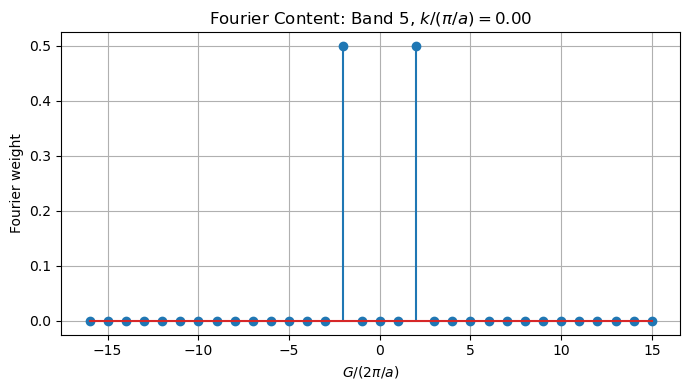

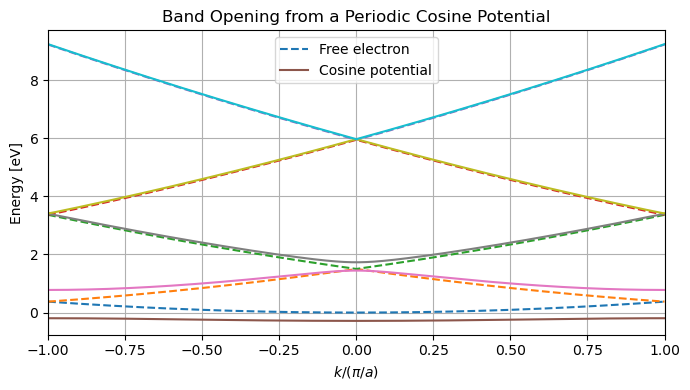

Estimated zone-boundary gap: 0.9730 eV
k/(pi/a) = 1.0000


In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Physical constants
hbar = 1.055e-34   # [J s]
m_e  = 9.109e-31   # [kg]
eV   = 1.602e-19   # [J]


def build_bloch_laplacian_1d(
    N: int,
    dx: float,
    k: float,
) -> sp.csr_matrix:
    """
    Construct the 1D finite-difference Laplacian on one cell
    with Bloch boundary conditions.

    The Bloch condition is

        psi(x + a) = exp(i k a) psi(x)

    where

        a = N dx
    """

    a = N * dx

    main = -2.0 * np.ones(N)
    off = np.ones(N - 1)

    L = sp.diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="lil",
        dtype=complex,
    )

    # Bloch boundary couplings
    L[0, -1] = np.exp(-1j * k * a)
    L[-1, 0] = np.exp(1j * k * a)

    return L.tocsr() / dx**2


def build_bloch_hamiltonian_1d(
    N: int,
    dx: float,
    k: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> sp.csr_matrix:
    """
    Construct the free-electron Bloch Hamiltonian

        H(k) = -(hbar^2 / 2m) L(k)
    """

    L_k = build_bloch_laplacian_1d(
        N=N,
        dx=dx,
        k=k,
    )

    H_k = -(hbar**2 / (2.0 * mass)) * L_k

    return H_k


def solve_bloch_state_1d(
    N: int,
    dx: float,
    k: float,
    N_bands: int,
    mass: float = m_e,
    hbar: float = hbar,
):
    """
    Solve the Bloch Hamiltonian at a single k.

    Returns
    -------
    eigvals : np.ndarray
        Lowest N_bands eigenvalues in joules.

    eigvecs : np.ndarray
        Corresponding eigenvectors as columns.
    """

    H_k = build_bloch_hamiltonian_1d(
        N=N,
        dx=dx,
        k=k,
        mass=mass,
        hbar=hbar,
    )

    eigvals, eigvecs = np.linalg.eigh(H_k.toarray())

    return eigvals[:N_bands], eigvecs[:, :N_bands]


def calculate_dispersion(
    k_vals: np.ndarray,
    N_bands: int,
    N: int,
    dx: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Compute the lowest N_bands eigenvalues of H(k)
    for each k in k_vals.
    """

    E_k = []

    for k in k_vals:
        eigvals, _ = solve_bloch_state_1d(
            N=N,
            dx=dx,
            k=k,
            N_bands=N_bands,
            mass=mass,
            hbar=hbar,
        )

        E_k.append(eigvals)

    return np.array(E_k)


def normalize_grid_state(
    psi: np.ndarray,
    dx: float,
) -> np.ndarray:
    """
    Normalize a sampled wavefunction so that

        sum |psi_j|^2 dx = 1
    """

    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx)

    return psi / norm


def plot_bloch_cell_state(
    N: int,
    dx: float,
    k: float,
    band_index: int,
    mass: float = m_e,
    hbar: float = hbar,
):
    """
    Plot the real part, imaginary part, and probability density
    of the cell eigenvector u_{n,k}.
    """

    eigvals, eigvecs = solve_bloch_state_1d(
        N=N,
        dx=dx,
        k=k,
        N_bands=band_index + 1,
        mass=mass,
        hbar=hbar,
    )

    E = eigvals[band_index]
    u = eigvecs[:, band_index]
    u = normalize_grid_state(u, dx)

    x = np.arange(N) * dx
    x_nm = x * 1e9

    a = N * dx
    k_scaled = k * a / np.pi

    plt.figure(figsize=(7, 4))

    plt.plot(
        x_nm,
        np.real(u),
        label=r"$\mathrm{Re}\,u_{n,k}(x)$",
    )

    plt.plot(
        x_nm,
        np.imag(u),
        label=r"$\mathrm{Im}\,u_{n,k}(x)$",
    )

    plt.plot(
        x_nm,
        np.abs(u)**2,
        label=r"$|u_{n,k}(x)|^2$",
    )

    plt.xlabel("x [nm]")
    plt.ylabel("Amplitude / density")
    plt.title(
        rf"Band {band_index + 1}, "
        rf"$k/(\pi/a)={k_scaled:.2f}$, "
        rf"$E={E / eV:.3f}$ eV"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_bloch_phase(
    N: int,
    dx: float,
    k: float,
    band_index: int,
):
    """
    Plot the unwrapped phase of the Bloch eigenvector.
    """

    eigvals, eigvecs = solve_bloch_state_1d(
        N=N,
        dx=dx,
        k=k,
        N_bands=band_index + 1,
    )

    u = eigvecs[:, band_index]
    u = normalize_grid_state(u, dx)

    x = np.arange(N) * dx
    x_nm = x * 1e9

    a = N * dx
    k_scaled = k * a / np.pi

    phase = np.unwrap(np.angle(u))

    plt.figure(figsize=(7, 4))

    plt.plot(
        x_nm,
        phase,
    )

    plt.xlabel("x [nm]")
    plt.ylabel(r"$\arg u_{n,k}(x)$")
    plt.title(
        rf"Phase of Band {band_index + 1}, "
        rf"$k/(\pi/a)={k_scaled:.2f}$"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def get_fourier_spectrum(
    u: np.ndarray,
    dx: float,
):
    """
    Compute the discrete Fourier spectrum of a sampled cell state.
    """

    N = len(u)

    coeffs = np.fft.fftshift(np.fft.fft(u))
    G_vals = 2.0 * np.pi * np.fft.fftshift(
        np.fft.fftfreq(N, d=dx)
    )

    weights = np.abs(coeffs)**2
    weights = weights / np.sum(weights)

    return G_vals, weights


def plot_fourier_content(
    N: int,
    dx: float,
    k: float,
    band_index: int,
):
    """
    Plot Fourier weights of the cell eigenvector.
    """

    eigvals, eigvecs = solve_bloch_state_1d(
        N=N,
        dx=dx,
        k=k,
        N_bands=band_index + 1,
    )

    u = eigvecs[:, band_index]
    u = normalize_grid_state(u, dx)

    G_vals, weights = get_fourier_spectrum(
        u=u,
        dx=dx,
    )

    a = N * dx
    G_scaled = G_vals * a / (2.0 * np.pi)
    k_scaled = k * a / np.pi

    plt.figure(figsize=(7, 4))

    plt.stem(
        G_scaled,
        weights,
    )

    plt.xlabel(r"$G/(2\pi/a)$")
    plt.ylabel("Fourier weight")
    plt.title(
        rf"Fourier Content: Band {band_index + 1}, "
        rf"$k/(\pi/a)={k_scaled:.2f}$"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def build_cosine_potential_1d(
    N: int,
    dx: float,
    V0_eV: float,
) -> sp.csr_matrix:
    """
    Construct a diagonal cosine potential

        V(x) = V0 cos(2 pi x / a)

    where V0 is supplied in eV.
    """

    a = N * dx
    x = np.arange(N) * dx

    V = V0_eV * eV * np.cos(
        2.0 * np.pi * x / a
    )

    return sp.diags(
        V,
        offsets=0,
        format="csr",
        dtype=complex,
    )


def build_bloch_hamiltonian_1d_with_potential(
    N: int,
    dx: float,
    k: float,
    V: sp.csr_matrix,
    mass: float = m_e,
    hbar: float = hbar,
) -> sp.csr_matrix:
    """
    Construct

        H(k) = T(k) + V
    """

    L_k = build_bloch_laplacian_1d(
        N=N,
        dx=dx,
        k=k,
    )

    T_k = -(hbar**2 / (2.0 * mass)) * L_k

    return T_k + V


def calculate_dispersion_with_potential(
    k_vals: np.ndarray,
    N_bands: int,
    N: int,
    dx: float,
    V: sp.csr_matrix,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Compute bands for

        H(k) = T(k) + V
    """

    E_k = []

    for k in k_vals:
        H_k = build_bloch_hamiltonian_1d_with_potential(
            N=N,
            dx=dx,
            k=k,
            V=V,
            mass=mass,
            hbar=hbar,
        )

        eigvals = np.linalg.eigvalsh(H_k.toarray())

        E_k.append(eigvals[:N_bands])

    return np.array(E_k)


def estimate_zone_boundary_gap(
    Ek_eV: np.ndarray,
    k_vals: np.ndarray,
    a: float,
    lower_band: int = 0,
    upper_band: int = 1,
):
    """
    Estimate the direct band gap at k = pi / a.
    """

    k_edge = np.pi / a
    idx = np.argmin(np.abs(k_vals - k_edge))

    gap = Ek_eV[idx, upper_band] - Ek_eV[idx, lower_band]

    return gap, idx


# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------

N_uc = 32
L_uc = 1e-9
dx = L_uc / N_uc

N_bands = 5

k_vals = np.linspace(
    -np.pi / L_uc,
    np.pi / L_uc,
    500,
)

k_vals_pi = k_vals * L_uc / np.pi


# Free-electron dispersion

Ek_free_eV = calculate_dispersion(
    k_vals=k_vals,
    N_bands=N_bands,
    N=N_uc,
    dx=dx,
) / eV

plt.figure(figsize=(7, 4))

for n in range(N_bands):
    plt.plot(
        k_vals_pi,
        Ek_free_eV[:, n],
        label=f"Band {n + 1}",
    )

plt.xlim([-1, 1])
plt.xlabel(r"$k/(\pi/a)$")
plt.ylabel("Energy [eV]")
plt.title("1D Free-Electron Band Structure")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Inspect selected free-electron states

plot_bloch_cell_state(
    N=N_uc,
    dx=dx,
    k=0.0,
    band_index=0,
)

plot_bloch_cell_state(
    N=N_uc,
    dx=dx,
    k=0.5 * np.pi / L_uc,
    band_index=0,
)

plot_bloch_cell_state(
    N=N_uc,
    dx=dx,
    k=np.pi / L_uc,
    band_index=0,
)


# Inspect phase structure

plot_bloch_phase(
    N=N_uc,
    dx=dx,
    k=0.5 * np.pi / L_uc,
    band_index=0,
)

plot_bloch_phase(
    N=N_uc,
    dx=dx,
    k=np.pi / L_uc,
    band_index=0,
)


# Inspect Fourier content

for band_index in range(N_bands):
    plot_fourier_content(
        N=N_uc,
        dx=dx,
        k=0.0,
        band_index=band_index,
    )


# Add a weak periodic potential

V0_eV = 1.0

V_cos = build_cosine_potential_1d(
    N=N_uc,
    dx=dx,
    V0_eV=V0_eV,
)

Ek_cos_eV = calculate_dispersion_with_potential(
    k_vals=k_vals,
    N_bands=N_bands,
    N=N_uc,
    dx=dx,
    V=V_cos,
) / eV


# Compare free-electron bands and cosine-potential bands

plt.figure(figsize=(7, 4))

for n in range(N_bands):
    plt.plot(
        k_vals_pi,
        Ek_free_eV[:, n],
        linestyle="--",
        label="Free electron" if n == 0 else None,
    )

for n in range(N_bands):
    plt.plot(
        k_vals_pi,
        Ek_cos_eV[:, n],
        label="Cosine potential" if n == 0 else None,
    )

plt.xlim([-1, 1])
plt.xlabel(r"$k/(\pi/a)$")
plt.ylabel("Energy [eV]")
plt.title("Band Opening from a Periodic Cosine Potential")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Estimate the zone-boundary gap

gap_eV, idx_edge = estimate_zone_boundary_gap(
    Ek_eV=Ek_cos_eV,
    k_vals=k_vals,
    a=L_uc,
    lower_band=0,
    upper_band=1,
)

print(f"Estimated zone-boundary gap: {gap_eV:.4f} eV")
print(f"k/(pi/a) = {k_vals_pi[idx_edge]:.4f}")